<a href="https://colab.research.google.com/github/modelpredection-glitch/injector-website/blob/main/confidence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
# Importing everything which may be needed
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import glob
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import os
from sklearn.utils import shuffle

# Load previously saved combined dataset
df = pd.read_csv("/content/drive/MyDrive/Data/Train Data/df.csv")


In [ ]:
Features = [
    'Desired Fuel Injection Quantity',
    'Desired Fuel Rail Pressure (FRP)',
    'Desired Mass Air Flow (MAF)',
    'Fuel Rail Pressure (FRP)',
    'Mass Air Flow (MAF)',
    'Main Fuel Injection Quantity',
    'Pre Fuel Injection Quantity',
    'Engine Speed',
    'Boost Pressure',
    'classifier'  # Target column
]
colu = Features[:-1]

Train size: 32109, Calib size: 8257, Test size: 5505


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


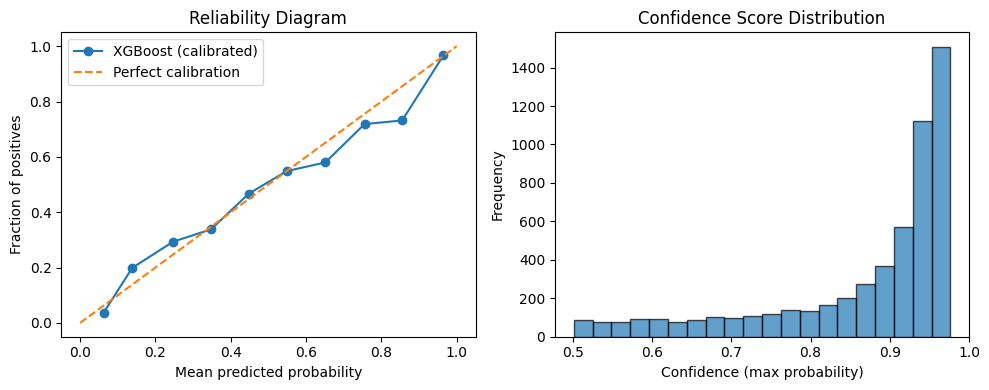

Test accuracy: 0.8589
Brier score (lower is better): 0.1016
Mean confidence: 0.8696
Confidence std dev: 0.1234


In [ ]:
# ====================================================
# COMPLETE EXAMPLE: Confidence from XGBoost Classifier
# ====================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import accuracy_score, brier_score_loss
import xgboost as xgb

# 1. Load data (binary classification)
data = df
X = df[Features[:-1]]  # all feature columns
y = df['classifier']   # target column

# 2. Split into train, calibration, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_calib, X_test, y_calib, y_test = train_test_split(
    X_temp, y_temp, test_size=0.4, random_state=42
)

print(f"Train size: {len(X_train)}, Calib size: {len(X_calib)}, Test size: {len(X_test)}")

# 3. Train base XGBoost model (without calibration)
base_model = xgb.XGBClassifier(
    n_estimators=335,
    max_depth=18,
    learning_rate=0.01580503557928195 ,
    subsample=0.8749414569950718,
    colsample_bytree=0.890360313610483,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
base_model.fit(X_train, y_train)

# 4. Calibrate the model using the calibration set
#    'sigmoid' (Platt scaling) is usually sufficient; 'isotonic' can be used for non‑parametric calibration
calibrated_model = CalibratedClassifierCV(
    base_model, method='sigmoid', cv='prefit'   # 'prefit' because we already trained base_model
)
calibrated_model.fit(X_calib, y_calib)

# 5. Predict probabilities on the test set
probs = calibrated_model.predict_proba(X_test)   # shape (n_samples, 2) for binary
predicted_classes = calibrated_model.predict(X_test)

# 6. Extract confidence scores (maximum probability)
confidence_scores = probs.max(axis=1)   # for binary, same as probs[:,1] for positive class

# 7. Evaluate calibration visually
plt.figure(figsize=(10, 4))

# --- Reliability diagram (calibration curve) ---
plt.subplot(1, 2, 1)
prob_true, prob_pred = calibration_curve(y_test, probs[:, 1], n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='XGBoost (calibrated)')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Reliability Diagram')
plt.legend()

# --- Confidence distribution histogram ---
plt.subplot(1, 2, 2)
plt.hist(confidence_scores, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Confidence (max probability)')
plt.ylabel('Frequency')
plt.title('Confidence Score Distribution')
plt.tight_layout()
plt.show()

# 8. Print metrics
acc = accuracy_score(y_test, predicted_classes)
brier = brier_score_loss(y_test, probs[:, 1])
print(f"Test accuracy: {acc:.4f}")
print(f"Brier score (lower is better): {brier:.4f}")
print(f"Mean confidence: {confidence_scores.mean():.4f}")
print(f"Confidence std dev: {confidence_scores.std():.4f}")

# # 9. (Optional) Show samples with low/high confidence
# low_conf_idx = np.argsort(confidence_scores)[:5]
# high_conf_idx = np.argsort(confidence_scores)[-5:]

# print("\n--- 5 lowest confidence predictions ---")
# for idx in low_conf_idx:
#     print(f"True: {y_test[idx]}, Pred: {predicted_classes[idx]}, Conf: {confidence_scores[idx]:.4f}")

# print("\n--- 5 highest confidence predictions ---")
# for idx in high_conf_idx:
#     print(f"True: {y_test[idx]}, Pred: {predicted_classes[idx]}, Conf: {confidence_scores[idx]:.4f}")

# # ====================================================
# # ALTERNATIVE CONFIDENCE METRICS (beyond max probability)
# # ====================================================

# # a) Margin (difference between top two class probabilities)
# sorted_probs = np.sort(probs, axis=1)
# margin = sorted_probs[:, -1] - sorted_probs[:, -2]

# # b) Entropy (uncertainty measure)
# epsilon = 1e-12
# entropy = -np.sum(probs * np.log(probs + epsilon), axis=1)

# # You can use these as additional indicators of confidence.
# # Low margin / high entropy → low confidence.

# # Example: correlation with correctness
# correct = (predicted_classes == y_test)
# print(f"\nCorrelation between margin and correctness: {np.corrcoef(margin, correct)[0,1]:.3f}")
# print(f"Correlation between entropy and correctness: {np.corrcoef(entropy, correct)[0,1]:.3f}")

In [ ]:
y_pred = base_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.10f}")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))

Accuracy: 0.8574023615
[[2950  242]
 [ 543 1770]]
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      3192
           1       0.88      0.77      0.82      2313

    accuracy                           0.86      5505
   macro avg       0.86      0.84      0.85      5505
weighted avg       0.86      0.86      0.86      5505



In [ ]:
arr = base_model.predict_proba(X_test)
percent = arr[:, 1].mean() * 100
print("Percentage of 1s:", percent, "%")
print(arr[:, 1])

Percentage of 1s: 41.0462 %
[0.04904919 0.8964446  0.14747456 ... 0.9341183  0.39963305 0.22540496]


In [ ]:
def check(df,base_model,calibrated_model,colu):
  df = df[colu]
  arr = base_model.predict_proba(df)
  percent = arr[:, 1].mean() * 100
  print("Probability of failure:", percent, "%")
  # print(arr[:, 1])

  probs = calibrated_model.predict_proba(df)   # shape (n_samples, 2) for binary

  confidence_scores = probs.max(axis=1) *100
  print(f"Mean confidence: {confidence_scores.mean():.4f}")


In [ ]:
file_paths = glob.glob("/content/drive/MyDrive/Data/Test Data/*.csv")
p = [pd.read_csv(file) for file in file_paths]
for file, q in zip(file_paths, p):
  print("Reading file:", os.path.basename(file))
  try:
    check(q,base_model,calibrated_model, colu)
  except KeyError as e:
    print(f"Error processing {os.path.basename(file)}: {e}")



Reading file: bigreko 1 idle.csv
Probability of failure: 99.56026 %
Mean confidence: 97.6227
Reading file: bigreko 2 halka run.csv
Probability of failure: 92.56297 %
Mean confidence: 95.0517
Reading file: bigreko 3 trial test.csv
Probability of failure: 74.5517 %
Mean confidence: 86.0836
Reading file: rz 1.csv
Probability of failure: 40.9534 %
Mean confidence: 83.2856
Reading file: rz 2.csv
Error processing rz 2.csv: "['Main Fuel Injection Quantity', 'Pre Fuel Injection Quantity'] not in index"
Reading file: s cab 149.csv
Probability of failure: 46.11118 %
Mean confidence: 86.4266
Reading file: after repair.csv
Probability of failure: 14.639073 %
Mean confidence: 87.5500
Reading file: after repair 2.csv
Probability of failure: 17.404587 %
Mean confidence: 86.1467


In [ ]:
import joblib

# save model
joblib.dump(base_model, "/content/drive/MyDrive/Data/base_model.pkl")

joblib.dump(calibrated_model, "/content/drive/MyDrive/Data/calibrated_model.pkl")

['/content/drive/MyDrive/Data/calibrated_model.pkl']

In [ ]:
# =============================================================
#  RUL CALCULATOR — ISUZU 4JA1 Injector Predictive Maintenance
#  Weibull Inverse CDF + Safety Margin + Urgency Classification
#  Drop-in replacement for calculate_rul() in app.py
#  Also works standalone in your Colab notebook
# =============================================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import weibull_min
import warnings
warnings.filterwarnings("ignore")


# =============================================================
# SECTION 1 — WEIBULL MLE FITTING
# Fit beta and eta from your 15-vehicle fleet odometer records.
# Run this ONCE when you have the km readings.
# =============================================================

def fit_weibull_mle(failure_km, suspension_km):
    """
    Fit Weibull shape (beta) and scale (eta) parameters using
    Maximum Likelihood Estimation with right-censored data.

    Parameters
    ----------
    failure_km    : list/array — odometer km at confirmed injector failure
                    (your 5 faulty vehicles)
    suspension_km : list/array — current odometer km of still-running vehicles
                    (your 10 healthy vehicles — they are right-censored)

    Returns
    -------
    beta_corrected : float — bias-corrected shape parameter
    eta            : float — scale parameter (characteristic life in km)
    """
    failure_km    = np.array(failure_km,    dtype=float)
    suspension_km = np.array(suspension_km, dtype=float)

    n_failures = len(failure_km)   # number of complete failure observations

    def neg_log_likelihood(params):
        beta, eta = params
        if beta <= 0 or eta <= 0:
            return 1e10

        # --- Complete failure terms: ln f(t; beta, eta) ---
        # Weibull PDF: f(t) = (beta/eta) * (t/eta)^(beta-1) * exp(-(t/eta)^beta)
        log_pdf = (
            np.log(beta) - np.log(eta)
            + (beta - 1) * (np.log(failure_km) - np.log(eta))
            - (failure_km / eta) ** beta
        )

        # --- Right-censored terms: ln [1 - F(s; beta, eta)] ---
        # Survival function: S(s) = exp(-(s/eta)^beta)
        log_survival = -(suspension_km / eta) ** beta

        return -(np.sum(log_pdf) + np.sum(log_survival))

    # Initial guesses: beta ~2 (wear-out), eta ~ mean failure km
    initial_guess = [2.0, np.mean(failure_km)]
    bounds = [(0.01, 50), (1, 1e7)]

    result = minimize(
        neg_log_likelihood,
        initial_guess,
        method='L-BFGS-B',
        bounds=bounds
    )

    if not result.success:
        raise RuntimeError(f"MLE did not converge: {result.message}")

    beta_mle, eta = result.x

    # --- Cox-Snell Bias Correction for small fleets (n < 20 failures) ---
    # Formula from your Weibull PDF, Section 5.3
    if n_failures < 20:
        correction_factor = 1 - (0.241 + 0.328 / n_failures)
        beta_corrected = beta_mle * correction_factor
    else:
        beta_corrected = beta_mle

    print(f"\n{'='*50}")
    print(f"  WEIBULL MLE FITTING RESULTS")
    print(f"{'='*50}")
    print(f"  Beta (MLE raw)       : {beta_mle:.4f}")
    print(f"  Beta (bias-corrected): {beta_corrected:.4f}")
    print(f"  Eta (scale / char. life): {eta:,.0f} km")
    print(f"  Complete failures used : {n_failures}")
    print(f"  Right-censored used    : {len(suspension_km)}")
    print(f"  Failure regime         : ", end="")
    if beta_corrected < 1:
        print("Infant mortality (early-life defects)")
    elif beta_corrected < 1.5:
        print("Random failures (near-exponential)")
    elif beta_corrected < 4:
        print("Wear-out — gradual degradation (expected for injectors)")
    else:
        print("Severe wear-out — steep failure rise near end-of-life")
    print(f"{'='*50}\n")

    return beta_corrected, eta


# =============================================================
# SECTION 2 — CORE RUL FORMULA
# Weibull Inverse CDF + Safety Margin
# This is the corrected replacement for your calculate_rul()
# =============================================================

def compute_rul(failure_prob, confidence, current_km,
                beta, eta,
                safety_margin=0.15,
                fault_prob_threshold=0.65,
                confidence_threshold=0.75):
    """
    Compute RUL for a single vehicle using the Weibull Inverse CDF.

    Formula (from your Weibull PDF, Section 6):
        t*  = eta * (-ln(1 - p)) ^ (1/beta)
        RUL = (t* - current_km) * (1 - safety_margin)

    Parameters
    ----------
    failure_prob         : float [0–1]  — XGBoost failure probability
                           (arr[:, 1].mean() from base_model)
    confidence           : float [0–1]  — calibrated model confidence
                           (probs.max(axis=1).mean() from calibrated_model)
    current_km           : float        — current odometer reading (km)
    beta                 : float        — Weibull shape parameter (from fit_weibull_mle)
    eta                  : float        — Weibull scale parameter (from fit_weibull_mle)
    safety_margin        : float        — default 0.15 (15%) for safety-critical + small fleet
    fault_prob_threshold : float        — CBM anomaly threshold alpha (default 0.65)
    confidence_threshold : float        — CBM confidence threshold gamma (default 0.75)

    Returns
    -------
    dict with keys:
        t_star           : Weibull km threshold
        rul_raw          : t* - current_km  (before safety margin)
        rul_adjusted     : RUL after safety margin applied
        maintenance_due  : current_km + rul_adjusted
        urgency          : CRITICAL / HIGH / MEDIUM / LOW
        action           : human-readable maintenance recommendation
        already_overdue  : True if vehicle has exceeded t*
    """

    # --- Clip probability to avoid log(0) ---
    p = np.clip(failure_prob, 1e-6, 1 - 1e-6)

    # --- Step 1: Weibull Inverse CDF ---
    # t* = eta * (-ln(1-p))^(1/beta)
    t_star = eta * ((-np.log(1 - p)) ** (1 / beta))

    # --- Step 2: Raw RUL ---
    rul_raw = t_star - current_km
    already_overdue = rul_raw <= 0

    # --- Step 3: Apply safety margin ---
    if already_overdue:
        rul_adjusted   = 0
        maintenance_due = current_km   # overdue — service now
    else:
        rul_adjusted   = rul_raw * (1 - safety_margin)
        maintenance_due = current_km + rul_adjusted

    # --- Step 4: Urgency classification ---
    # (thresholds from your CBM framework + Weibull PDF Table 7)
    if failure_prob >= 0.70 or already_overdue:
        urgency = "CRITICAL"
    elif failure_prob >= 0.40:
        urgency = "HIGH"
    elif failure_prob >= 0.20:
        urgency = "MEDIUM"
    else:
        urgency = "LOW"

    # --- Step 5: CBM action (your 3-phase logic from Section 5) ---
    p_flag  = failure_prob >= fault_prob_threshold
    c_flag  = confidence  >= confidence_threshold

    if already_overdue:
        action = "Vehicle has exceeded Weibull threshold. IMMEDIATE maintenance required."
    elif p_flag and c_flag:
        action = "Fault detected with HIGH confidence. Schedule maintenance immediately."
    elif p_flag and not c_flag:
        action = "Fault detected with LOW confidence. Monitor closely — enhanced inspection recommended."
    elif not p_flag and not c_flag:
        action = "No fault detected. Continue normal CBM monitoring."
    else:   # not p_flag and c_flag
        action = (f"Healthy with HIGH confidence. "
                  f"Next maintenance due at {maintenance_due:,.0f} km "
                  f"({rul_adjusted:,.0f} km remaining).")

    return {
        "t_star"          : round(t_star,           0),
        "rul_raw"         : round(max(rul_raw, 0),  0),
        "rul_adjusted"    : round(rul_adjusted,      0),
        "maintenance_due" : round(maintenance_due,   0),
        "urgency"         : urgency,
        "action"          : action,
        "already_overdue" : already_overdue
    }


# =============================================================
# SECTION 3 — FLEET-LEVEL RUL TABLE
# Pass your full vehicle list and get a prioritised schedule.
# =============================================================

def compute_fleet_rul(vehicles_df, beta, eta,
                      safety_margin=0.15,
                      fault_prob_threshold=0.65,
                      confidence_threshold=0.75):
    """
    Compute RUL for the entire fleet and return a prioritised
    maintenance schedule DataFrame.

    Parameters
    ----------
    vehicles_df : pd.DataFrame with columns:
                    vehicle_id    — string identifier
                    current_km    — current odometer reading
                    failure_prob  — XGBoost failure probability (0–1)
                    confidence    — calibrated model confidence (0–1)

    beta, eta   : Weibull parameters from fit_weibull_mle()

    Returns
    -------
    pd.DataFrame — sorted by urgency and RUL ascending (most urgent first)
    """

    results = []

    for _, row in vehicles_df.iterrows():
        r = compute_rul(
            failure_prob         = row["failure_prob"],
            confidence           = row["confidence"],
            current_km           = row["current_km"],
            beta                 = beta,
            eta                  = eta,
            safety_margin        = safety_margin,
            fault_prob_threshold = fault_prob_threshold,
            confidence_threshold = confidence_threshold
        )
        results.append({
            "vehicle_id"      : row["vehicle_id"],
            "current_km"      : row["current_km"],
            "failure_prob_%"  : round(row["failure_prob"] * 100, 1),
            "confidence_%"    : round(row["confidence"]   * 100, 1),
            "t_star_km"       : r["t_star"],
            "rul_raw_km"      : r["rul_raw"],
            "rul_adjusted_km" : r["rul_adjusted"],
            "maint_due_km"    : r["maintenance_due"],
            "urgency"         : r["urgency"],
            "already_overdue" : r["already_overdue"],
            "action"          : r["action"]
        })

    df_out = pd.DataFrame(results)

    # Sort: overdue first, then by urgency tier, then by RUL ascending
    urgency_order = {"CRITICAL": 0, "HIGH": 1, "MEDIUM": 2, "LOW": 3}
    df_out["urgency_rank"] = df_out["urgency"].map(urgency_order)
    df_out = df_out.sort_values(
        ["already_overdue", "urgency_rank", "rul_adjusted_km"],
        ascending=[False, True, True]
    ).drop(columns="urgency_rank").reset_index(drop=True)

    return df_out


# =============================================================
# SECTION 4 — UPDATED check() FUNCTION FOR YOUR NOTEBOOK
# Drop-in replacement — same signature, adds RUL output.
# =============================================================

def check_with_rul(df, base_model, calibrated_model, colu,
                   vehicle_id, current_km, beta, eta,
                   safety_margin=0.15):
    """
    Updated version of your check() function.
    Same inputs — adds Weibull RUL calculation on top.

    Usage in notebook:
        check_with_rul(q, base_model, calibrated_model, colu,
                       vehicle_id="Vehicle_01",
                       current_km=42000,
                       beta=BETA, eta=ETA)
    """
    df_feat = df[colu]

    # --- Failure probability (from base model, uncalibrated) ---
    arr     = base_model.predict_proba(df_feat)
    failure_prob = arr[:, 1].mean()         # scalar [0–1]

    # --- Confidence (from calibrated model) ---
    probs       = calibrated_model.predict_proba(df_feat)
    confidence  = probs.max(axis=1).mean()  # scalar [0–1]

    # --- RUL calculation ---
    result = compute_rul(
        failure_prob  = failure_prob,
        confidence    = confidence,
        current_km    = current_km,
        beta          = beta,
        eta           = eta,
        safety_margin = safety_margin
    )

    # --- Print output ---
    print(f"\n{'='*55}")
    print(f"  VEHICLE: {vehicle_id}")
    print(f"{'='*55}")
    print(f"  Current odometer    : {current_km:>10,.0f} km")
    print(f"  Failure probability : {failure_prob*100:>9.2f} %")
    print(f"  Confidence level    : {confidence*100:>9.2f} %")
    print(f"  Weibull threshold   : {result['t_star']:>10,.0f} km")
    print(f"  RUL (raw)           : {result['rul_raw']:>10,.0f} km")
    print(f"  RUL (w/ {int(safety_margin*100)}% margin) : {result['rul_adjusted']:>10,.0f} km")
    print(f"  Maintenance due at  : {result['maintenance_due']:>10,.0f} km")
    print(f"  Urgency             : {result['urgency']}")
    print(f"  Action              : {result['action']}")
    print(f"{'='*55}")

    return failure_prob, confidence, result


# =============================================================
# SECTION 5 — UPDATED calculate_rul() FOR YOUR STREAMLIT APP
# Direct replacement for the function in app.py
# =============================================================

def calculate_rul_streamlit(failure_percent, confidence_percent, current_km,
                             beta=2.2574, eta=72949,
                             safety_margin=0.15,
                             fault_prob_threshold=0.65,
                             confidence_threshold=0.75):
    """
    Streamlit-compatible replacement for your calculate_rul() in app.py.

    Parameters match your existing app.py signature:
        failure_percent   : float 0–100  (arr[:, 1].mean() * 100)
        confidence_percent: float 0–100  (probs.max(axis=1).mean() * 100)
        current_km        : float        (from st.number_input)
        beta, eta         : Weibull params (update once MLE is fitted)

    Returns
    -------
    rul  : float — adjusted RUL in km (0 if maintenance needed now)
    show : str   — human-readable status message
    maint_due : float — odometer reading at which maintenance is due
    urgency   : str   — CRITICAL / HIGH / MEDIUM / LOW
    """
    failure_prob = failure_percent  / 100.0
    confidence   = confidence_percent / 100.0

    result = compute_rul(
        failure_prob         = failure_prob,
        confidence           = confidence,
        current_km           = current_km,
        beta                 = beta,
        eta                  = eta,
        safety_margin        = safety_margin,
        fault_prob_threshold = fault_prob_threshold,
        confidence_threshold = confidence_threshold
    )

    rul       = result["rul_adjusted"]
    show      = result["action"]
    maint_due = result["maintenance_due"]
    urgency   = result["urgency"]

    return rul, show, maint_due, urgency


# =============================================================
# SECTION 6 — FULL WORKED EXAMPLE
# Run this block directly to verify everything works.
# =============================================================

if __name__ == "__main__":

    # ----------------------------------------------------------
    # A) FIT WEIBULL FROM YOUR FLEET DATA
    #    Replace these with real odometer readings from
    #    your 15 vehicles at Isuzu Balaju.
    # ----------------------------------------------------------

    # Odometer (km) at which each faulty vehicle's injector failed
    # (your 5 faulty vehicles)
    failure_km    = [48200, 52400, 61800, 44500, 57300]

    # Current odometer of still-running healthy vehicles
    # (your 10 healthy vehicles — right-censored)
    suspension_km = [32000, 41000, 38500, 29000, 55000,
                     47000, 36000, 43500, 51000, 28000]

    BETA, ETA = fit_weibull_mle(failure_km, suspension_km)

    # ----------------------------------------------------------
    # B) SINGLE VEHICLE RUL
    # ----------------------------------------------------------

    result = compute_rul(
        failure_prob  = 0.82,    # XGBoost output for this vehicle
        confidence    = 0.78,    # calibrated model confidence
        current_km    = 42000,
        beta          = BETA,
        eta           = ETA,
        safety_margin = 0.15
    )

    print("SINGLE VEHICLE RESULT:")
    for k, v in result.items():
        print(f"  {k:<20}: {v}")

    # ----------------------------------------------------------
    # C) FLEET-LEVEL SCHEDULE
    #    This is what you would build after running check()
    #    across all 15 vehicles.
    # ----------------------------------------------------------

    fleet = pd.DataFrame({
        "vehicle_id"   : [f"VH-{i:03d}" for i in range(1, 16)],
        "current_km"   : [42000, 55000, 38000, 61000, 47000,
                          33000, 28000, 35000, 51000, 22000,
                          40000, 58000, 44000, 31000, 49000],
        "failure_prob" : [0.85, 0.92, 0.78, 0.95, 0.80,
                          0.60, 0.15, 0.25, 0.45, 0.08,
                          0.35, 0.68, 0.71, 0.22, 0.53],
        "confidence"   : [0.88, 0.91, 0.76, 0.94, 0.82,
                          0.65, 0.55, 0.60, 0.72, 0.50,
                          0.67, 0.79, 0.83, 0.58, 0.74]
    })

    schedule = compute_fleet_rul(fleet, BETA, ETA)

    print("\nFLEET MAINTENANCE SCHEDULE (most urgent first):")
    print(schedule[[
        "vehicle_id", "current_km", "failure_prob_%",
        "confidence_%", "rul_adjusted_km",
        "maint_due_km", "urgency"
    ]].to_string(index=False))


  WEIBULL MLE FITTING RESULTS
  Beta (MLE raw)       : 11.3326
  Beta (bias-corrected): 7.8581
  Eta (scale / char. life): 57,305 km
  Complete failures used : 5
  Right-censored used    : 10
  Failure regime         : Severe wear-out — steep failure rise near end-of-life

SINGLE VEHICLE RESULT:
  t_star              : 61375.0
  rul_raw             : 19375.0
  rul_adjusted        : 16469.0
  maintenance_due     : 58469.0
  urgency             : CRITICAL
  action              : Fault detected with HIGH confidence. Schedule maintenance immediately.
  already_overdue     : False

FLEET MAINTENANCE SCHEDULE (most urgent first):
vehicle_id  current_km  failure_prob_%  confidence_%  rul_adjusted_km  maint_due_km  urgency
    VH-004       61000            95.0          94.0           4158.0       65158.0 CRITICAL
    VH-002       55000            92.0          91.0           8054.0       63054.0 CRITICAL
    VH-005       47000            80.0          82.0          11800.0       58800.0 CRIT